In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('stock_data.csv')
print(df.head())
print(df.info())

         Date    Open    High     Low   Close  Volume  OpenInt
0  2010-07-21  24.333  24.333  23.946  23.946   43321        0
1  2010-07-22  24.644  24.644  24.362  24.487   18031        0
2  2010-07-23  24.759  24.759  24.314  24.507    8897        0
3  2010-07-26  24.624  24.624  24.449  24.595   19443        0
4  2010-07-27  24.477  24.517  24.431  24.517    8456        0
<class 'pandas.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     1565 non-null   str    
 1   Open     1565 non-null   float64
 2   High     1565 non-null   float64
 3   Low      1565 non-null   float64
 4   Close    1565 non-null   float64
 5   Volume   1565 non-null   int64  
 6   OpenInt  1565 non-null   int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 85.7 KB
None


In [23]:
log_returns = np.log(df['Close'] / df['Close'].shift(1))
df['LogReturns'] = log_returns.fillna(0)
print(df[['Close', 'LogReturns']].head())   

    Close  LogReturns
0  23.946    0.000000
1  24.487    0.022341
2  24.507    0.000816
3  24.595    0.003584
4  24.517   -0.003176


In [24]:
u = df['LogReturns'].mean()
var = df['LogReturns'].var()
drift = u - (0.5 * var)
stdev = df['LogReturns'].std()

In [25]:
simulation_df = pd.DataFrame()
last_price = df['Close'].iloc[-1]
for i in range(1000):
    prices_series = []
    price = last_price
    for j in range(30):
        z=np.random.normal()
        daily_return = np.exp(drift + stdev * z)
        price = price * daily_return
        
        prices_series.append(price)
    
    # Save this path into the dataframe
    simulation_df[i] = prices_series

C:\Users\ACER\AppData\Local\Temp\ipykernel_1804\921363989.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  simulation_df[i] = prices_series


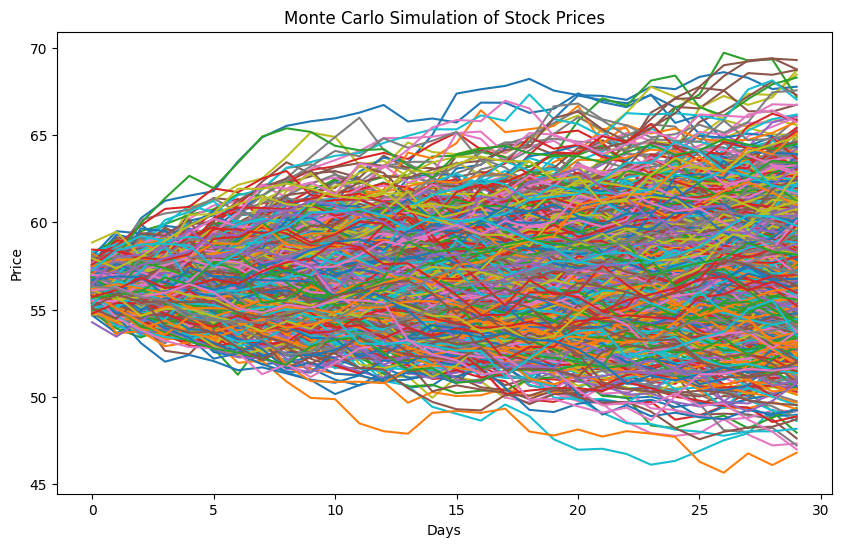

<Figure size 640x480 with 0 Axes>

In [29]:
plt.figure(figsize=(10,6))
plt.plot(simulation_df)
plt.xlabel('Days')
plt.ylabel('Price')
plt.title('Monte Carlo Simulation of Stock Prices')
plt.show()
plt.savefig('monte_carlo_simulation.png')

In [30]:
simulation_df.to_csv('monte_carlo_simulation.csv')